# Manual implementation of radon transform

We have seen how the radon transform is the "line integral" of an image along multiple angles.
Try to implement it manually using
* scipy.ndimage.rotate
* np.sum

Compare the results with skimage.transform.radon

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

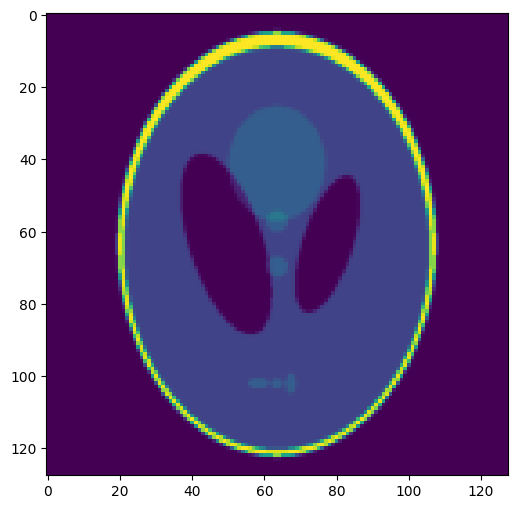

In [2]:
import skimage.data
from skimage.transform import radon, iradon
nPix = 128
plt.figure(figsize=(6,6))
immFull = skimage.data.shepp_logan_phantom()
imm = skimage.transform.resize(immFull,(nPix,nPix),anti_aliasing=True)
plt.imshow(imm)

## 1. Implement the forward projection

Think how it should work. As in the other notebook, you will need to define a number of angles.
Preallocate a sinogram vector: which dimensions does it have? (How should you set the "reshape" parameter of rotate?)

## 2. Implement the transposedvoperation: backprojection
In a backprojection you add to every pixel that sits along a projection line the sinogram value. Also this can be done using only ndi.rotate and a sum (you'll likely need to broadcast along one axis)


# 3. Implement the filter for a full reconstruction!

These 2 approaches are (in an ideal world) equivalent:
1. filter the sinogram -> backproject
2. backproject -> filter the image

Filtering is a convolution operation, which is a multiplication in Fourier space.
Try the following:
1. Define an empty image of the same size of the image you're working with. Set the central pixel to 1.
2. Apply the forward and back projection to it
3. Take the fourier transform of this and look at it! It should look like a hyperbole (BTW, how do you expect the real and imaginary part to be). The inverse (literally $1/x$ pixelwise) is what you need to filter for
4. Backproject the sinogram of the image you want to recontruct and take its fourier transform
5. Multiply it by the frequency spectrum of point 3
6. Take the inverse fourier transform. Up to numerical errors, it should work